## Librarie

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Loading Dataset

In [325]:
data_clean = pd.read_csv(r'D:\sharif\ADS\assignment1\AmesHousing_Final_Cleaned.csv', na_filter=False)
data_clean.shape

(2855, 68)

 ## Feature Engineering

In [326]:
data_fe = data_clean.copy()

### Ratio Features


**Density_Ratio**:
- Living Area / Lot Area 
- Construction density. Lower values mean larger yards.

In [327]:
data_fe['Density_Ratio'] = data_fe['Gr Liv Area'] / (data_fe['Lot Area'] + 1)

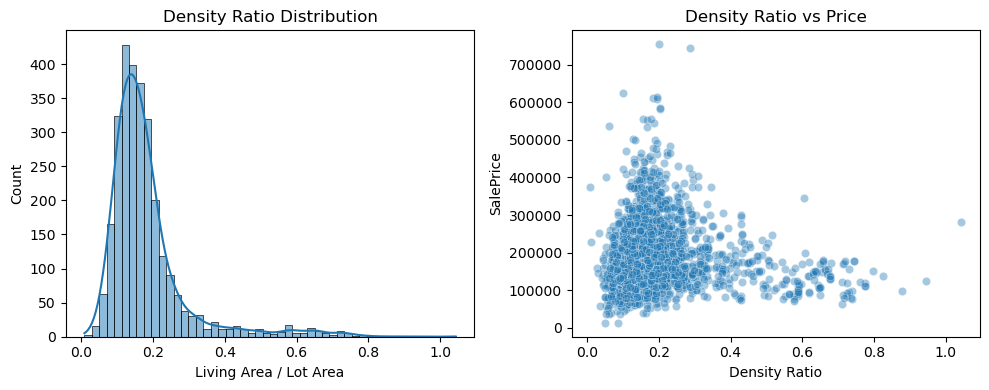

In [328]:
# histogram for showing distribution of Density_Ratio
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data_fe["Density_Ratio"], bins=50, kde=True)
plt.title("Density Ratio Distribution")
plt.xlabel("Living Area / Lot Area")

# scatter plot to show realation between Density_Ratio , SalePrice(target)
plt.subplot(1,2,2)
sns.scatterplot(x=data_fe["Density_Ratio"], y=data_fe['SalePrice'], alpha=0.4)
plt.xlabel("Density Ratio")
plt.ylabel("SalePrice")
plt.title("Density Ratio vs Price")
plt.tight_layout()
plt.show()

<!-- - Most houses have density below 0.4 (land is larger than the house).
- Expensive houses (>$400k) almost always have low density (<0.3).
- High-density houses (>0.6) are rare and typically lower-priced (townhouses or small lots). -->

**BathPerBed**
- Full Bath / Bedroom 
- Luxury indicator. Higher = more bathrooms per bedroom.

In [329]:
data_fe['BathPerBed'] = data_fe['Full Bath'] / (data_fe['Bedroom AbvGr'] + 1)

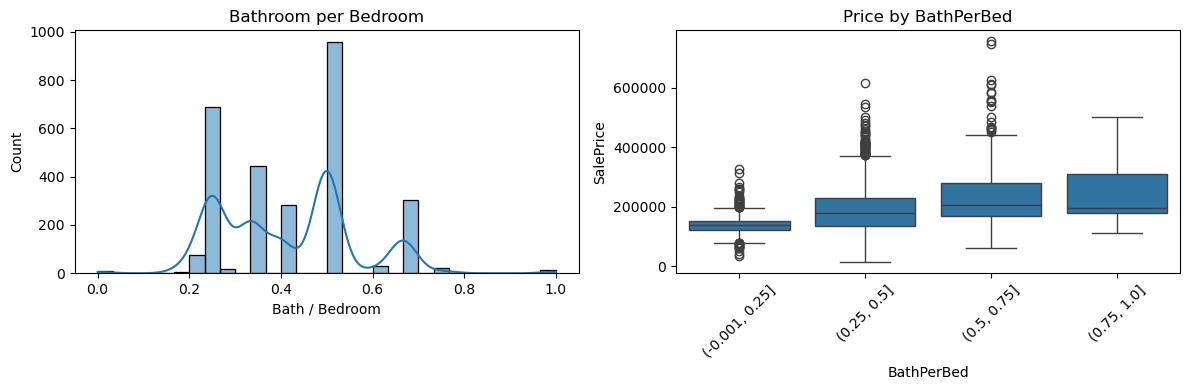

In [330]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data_fe["BathPerBed"], bins=30, kde=True)
plt.title("Bathroom per Bedroom")
plt.xlabel("Bath / Bedroom")

plt.subplot(1,2,2)
sns.boxplot(x=pd.cut(data_fe["BathPerBed"], bins=4), y=data_fe['SalePrice'])
plt.xticks(rotation=45)
plt.title("Price by BathPerBed")
plt.tight_layout()
plt.show()

- Standard homes: ~0.7 – 1.0 (one bath per bedroom)
- Most of houses have 0.5 BathPerBed (tow bath per bedroom)
- Luxury / large homes: bigger BathPerBed 

**Garage_per_Living**: 
- Garage Area / Gr Liv Area
- parking capacity relative to house size.


In [331]:
data_fe['Garage_per_Living'] = data_fe['Garage Area'] / (data_fe['Gr Liv Area'] + 1)

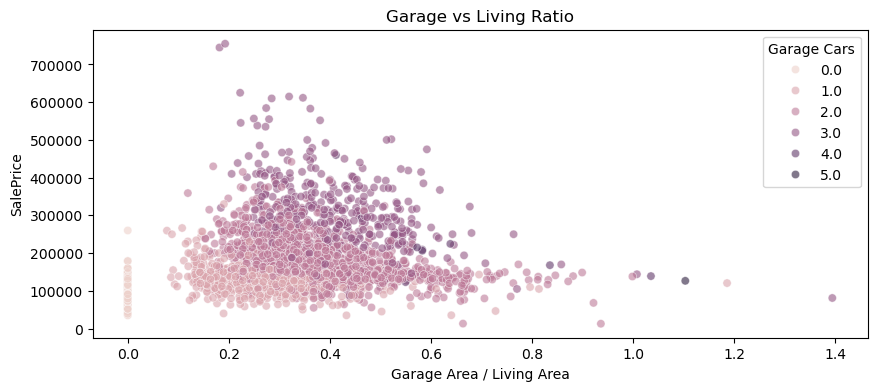

In [332]:
plt.figure(figsize=(10,4))
sns.scatterplot(x=data_fe["Garage_per_Living"], y=data_fe['SalePrice'], hue=data_fe["Garage Cars"], alpha=0.6)
plt.xlabel("Garage Area / Living Area")
plt.ylabel("SalePrice")
plt.title("Garage vs Living Ratio")
plt.legend(title="Garage Cars")
plt.show()

- Most houses cluster at ratio <0.2 with 1–2 garage cars → mid-range prices.
- Luxury houses (>$500k) typically have ratio >0.3 and 3+ garage cars.
- A few outliers with very high ratio but low price likely represent workshops or commercial use.

### Date/time transformations

- Create House_Age faeture that is the age of house.
- Create Years_Since_Remod feature that is the age of remodeling the house.

In [333]:
data_fe['House_Age'] = data_fe['Yr Sold'] - data_fe['Year Built']

data_fe['Years_Since_Remod'] = data_fe['Yr Sold'] - data_fe['Year Remod/Add']

data_fe = data_fe.drop(columns=['Year Built'])

### Binning

- House_Age was binned into: New, Medium, Old, Very Old.
- Years_Since_Remod was binned similarly.

In [334]:
data_fe[['House_Age', 'Years_Since_Remod']].describe()

,House_Age,Years_Since_Remod
count,2855.000000,2855.000000
mean,35.770578,23.357618
std,29.963600,20.807977
min,0.000000,-1.000000
25%,7.000000,4.000000
50%,34.000000,15.000000
75%,54.000000,42.000000
max,135.000000,60.000000


In [335]:
data_fe[(data_fe['Years_Since_Remod'] < 0)][['Yr Sold', 'Year Remod/Add']]

,Yr Sold,Year Remod/Add
1657,2007,2008


Oh, there is -1 for Years_Since_Remod. It's an invalid data.

We drop it.


In [336]:
data_fe = data_fe.drop(index=[1657])
print(data_fe.shape)

(2854, 72)


In [337]:
# bins are based on min , max of features
bins_age = [0, 7, 20, 50, 140]
bins_remod = [0, 5, 15, 30, 65]

data_fe["Age_Group"] = pd.cut(data_fe["House_Age"], bins=bins_age, labels=["Very New","New","Medium","Old"], include_lowest=True)
data_fe["Remod_Group"] = pd.cut(data_fe["Years_Since_Remod"], bins=bins_remod, labels=["Recent","Medium","Old","Very Old"], include_lowest=True)

In [338]:
data_fe[['House_Age', 'Age_Group', 'Years_Since_Remod', 'Remod_Group']].head()

,House_Age,Age_Group,Years_Since_Remod,Remod_Group
0,50,Medium,50,Very Old
1,49,Medium,49,Very Old
2,52,Old,52,Very Old
3,42,Medium,42,Very Old
4,13,New,12,Medium


### Aggregation

- **Neighborhood_AvgPrice**: captures the economic level of the neighborhood.
- **Zone_AvgPrice**: average price by MS Zoning (residential vs commercial).
- **SaleType_AvgPrice**: average price by Sale Type (normal vs new vs partial).

These features help the model capture **group-level trends** without overfitting.

In [339]:
neigh_price_mean = data_fe.groupby("Neighborhood")["SalePrice"].mean()
data_fe["Neighborhood_AvgPrice"] = data_fe["Neighborhood"].map(neigh_price_mean)

zone_price_mean = data_fe.groupby("MS Zoning")["SalePrice"].mean()
data_fe["Zone_AvgPrice"] = data_fe["MS Zoning"].map(zone_price_mean)

sale_price_mean = data_fe.groupby("Sale Type")["SalePrice"].mean()
data_fe["SaleType_AvgPrice"] = data_fe["Sale Type"].map(sale_price_mean)

In [340]:
data_fe[['Neighborhood', 'Neighborhood_AvgPrice', 'MS Zoning', 'Zone_AvgPrice', 'Sale Type', 'SaleType_AvgPrice']].tail(10)

,Neighborhood,Neighborhood_AvgPrice,MS Zoning,Zone_AvgPrice,Sale Type,SaleType_AvgPrice
2845,MeadowV,95756.486486,RM,126883.295711,WD,174436.858819
2846,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2847,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2848,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2849,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2850,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2851,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2852,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2853,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819
2854,Mitchel,162511.823009,RL,191252.783333,WD,174436.858819


### Mathematical Function

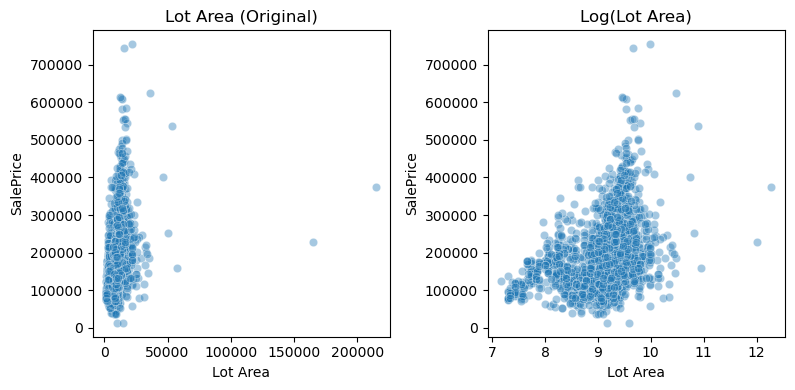

In [341]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.scatterplot(x=data_fe["Lot Area"], y=data_fe["SalePrice"], alpha=0.4)
plt.title("Lot Area (Original)")

plt.subplot(1,3,2)
sns.scatterplot(x=np.log1p(data_fe["Lot Area"]), y=data_fe["SalePrice"], alpha=0.4)
plt.title("Log(Lot Area)")

plt.tight_layout()
plt.show()

**log(Lot Area) (Lot_Area_log) as a new feature** beacause:
- The original Lot Area distribution is highly right‑skewed, with a few extremely large lots.
- Log transformation compresses the scale, making the relationship with SalePrice **closer to linear**.
- After log transform, the spread of points becomes more uniform, reducing the influence of extreme outliers.
- This helps linear models to better capture the effect of lot size on price without being dominated by rare large lots.

In [342]:
data_fe['Lot_Area_log'] = np.log1p(data_fe['Lot Area'])

### Feature Combinations

**Total_Bath** = Full Bath + 0.5 * Half Bath + Bsmt Full Bath→ realistic bathroom capacity.


In [343]:
data_fe['Total_Bath'] = data_fe["Full Bath"] + 0.5 * data_fe["Half Bath"] + data_fe["Bsmt Full Bath"]

data_fe[["Full Bath", "Half Bath", "Bsmt Full Bath", "Total_Bath"]].head()

,Full Bath,Half Bath,Bsmt Full Bath,Total_Bath
0,1,0,1.0,2.0
1,1,0,0.0,1.0
2,1,1,0.0,1.5
3,2,1,1.0,3.5
4,2,1,0.0,2.5


 **Quality_Score** averages key quality features 
- All quality‑related features were mapped to numeric values (Po=1, …, Ex=5, None=0).
- Then averaged to create Quality_Score (range 0–5).
- This single feature captures the **overall construction and finish quality** of the house.
- After mapping , the categorical quality features become redundant. So we drop them to reduce dimensionality and save it's numeric columns.

In [344]:
qual_features = ['Overall Qual','Kitchen Qual', 'Heating QC', 'Garage Qual', 'Fireplace Qu', 'Bsmt Qual', 'Exter Qual']

qual_mapping = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

# Overall Qual is numeric already
# mapping all quality features to numeric features
qual_cols_to_map = [col for col in qual_features if col != 'Overall Qual']
for col in qual_cols_to_map:
    data_fe[f"{col}_num"] = data_fe[col].map(qual_mapping)


data_fe["Quality_Score"] =  (
    data_fe["Overall Qual"] +
    data_fe["Kitchen Qual_num"] +
    data_fe["Heating QC_num"] +
    data_fe["Garage Qual_num"] +
    data_fe["Fireplace Qu_num"] +
    data_fe["Bsmt Qual_num"] +
    data_fe["Exter Qual_num"]
) / len(qual_features)

cols_to_drop = ["Kitchen Qual", "Heating QC", "Garage Qual", "Fireplace Qu", "Bsmt Qual", "Exter Qual"]
data_fe.drop(columns=cols_to_drop, inplace=True)

data_fe[["Overall Qual","Kitchen Qual_num","Heating QC_num","Garage Qual_num","Fireplace Qu_num","Bsmt Qual_num","Exter Qual_num","Quality_Score"]].head()

,Overall Qual,Kitchen Qual_num,Heating QC_num,Garage Qual_num,Fireplace Qu_num,Bsmt Qual_num,Exter Qual_num,Quality_Score
0,6,3,2,3,4,3,3,3.428571
1,5,3,3,3,0,3,3,2.857143
2,6,4,3,3,0,3,3,3.142857
3,7,5,5,3,3,3,4,4.285714
4,5,3,4,3,3,4,3,3.571429


In [345]:
data_fe.shape

(2854, 80)

In [346]:
# save dataset after Feature Engineering 
data_fe.to_csv("AmesHousing_After_FE.csv", index=False)

# Data Preprocessing

In this section we convert all categorical features to numerical values.

In [347]:
data_encoded = data_fe.copy()
print(f"Missing in copy: {data_encoded.isnull().sum().sum()}")
print(data_encoded.shape)

Missing in copy: 0
(2854, 80)


### Detecting Ordinal and Nomial features.

In [348]:
categorical_col = data_encoded.select_dtypes(include=['object', 'category']).columns

print(len(categorical_col))

for col in categorical_col:
    print(f"{col} : {data_encoded[col].unique()}")

33
MS Zoning : ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
Street : ['Pave' 'Grvl']
Lot Shape : ['IR1' 'Reg' 'IR2' 'IR3']
Land Contour : ['Lvl' 'HLS' 'Bnk' 'Low']
Lot Config : ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
Land Slope : ['Gtl' 'Mod' 'Sev']
Neighborhood : ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']
Condition 1 : ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']
Condition 2 : ['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn']
Bldg Type : ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']
House Style : ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']
Roof Style : ['Hip' 'Gable' 'Gambrel' 'Shed' 'Flat' 'Mansard']
Roof Matl : ['CompShg' 'Tar&Grv' 'WdShake' 'WdShngl' 'Roll' 'Metal']
Exterior 1st : ['Brk

In [349]:
ordinal_keywords = ['Qual', 'Cond', 'QC', 'Exposure', 'Finish', 'Paved', 'Functional']
ordinal_values = {'Po', 'Fa', 'TA', 'Gd', 'Ex', 'No', 'Mn', 'Av', 'Unf', 'RFn', 'Fin', 'Sal', 'Sev', 'Maj2', 'Maj1',
                   'Mod', 'Min2', 'Min1', 'Typ', 'N', 'P', 'Y', 'Very New', 'New', 'Medium', 'Old', 'Recent', 'Very Old'}

categorical_cols = data_encoded.select_dtypes(include=['object','category']).columns

ordinal_candidates = []
nominal_candidates = []

for col in categorical_cols:
    unique_vals = data_encoded[col].unique()
    n_unique = len(unique_vals)
    
    is_ordinal_by_name = any(keyword in col for keyword in ordinal_keywords)
    
    is_ordinal_by_count = 3 <= n_unique <= 8
    
    is_ordinal_by_values = any(val in ordinal_values for val in unique_vals)
    
    if is_ordinal_by_name or (is_ordinal_by_count and is_ordinal_by_values):
        ordinal_candidates.append(col)
    else:
        nominal_candidates.append(col)

print(f"\n Detected Ordinal candidates ({len(ordinal_candidates)}):")
for col in ordinal_candidates:
    print(f"   • {col}: values : {list(data_encoded[col].unique())[:5]}")

print(f"\n Detected Nomial candidates ({len(nominal_candidates)}):")
for col in nominal_candidates:
    print(f"   • {col}: {data_encoded[col].nunique()} unique values")

print(len(ordinal_candidates))    
print(len(nominal_candidates))


 Detected Ordinal candidates (15):
   • Land Slope: values : ['Gtl', 'Mod', 'Sev']
   • Condition 1: values : ['Norm', 'Feedr', 'PosN', 'RRNe', 'RRAe']
   • Condition 2: values : ['Norm', 'Feedr', 'PosA', 'PosN', 'Artery']
   • Exter Cond: values : ['TA', 'Gd', 'Fa', 'Po', 'Ex']
   • Bsmt Cond: values : ['Gd', 'TA', 'None', 'Po', 'Fa']
   • Bsmt Exposure: values : ['Gd', 'No', 'Mn', 'Av', 'None']
   • BsmtFin Type 1: values : ['BLQ', 'Rec', 'ALQ', 'GLQ', 'Unf']
   • BsmtFin Type 2: values : ['Unf', 'LwQ', 'BLQ', 'Rec', 'None']
   • Functional: values : ['Typ', 'Mod', 'Min1', 'Min2', 'Maj1']
   • Garage Finish: values : ['Fin', 'Unf', 'RFn', 'None']
   • Garage Cond: values : ['TA', 'None', 'Fa', 'Gd', 'Ex']
   • Paved Drive: values : ['P', 'Y', 'N']
   • Sale Condition: values : ['Normal', 'Partial', 'Family', 'Abnorml', 'Alloca']
   • Age_Group: values : ['Medium', 'Old', 'New', 'Very New']
   • Remod_Group: values : ['Very Old', 'Medium', 'Old', 'Recent']

 Detected Nomial candidate

Do Ordinal Encoding for Ordinal faetures

In [350]:
ordinal_mappings = {}

for col in ordinal_candidates:
    avg_price = data_fe.groupby(col)['SalePrice'].mean().sort_values()
    
    ordered_values = avg_price.index.tolist()
    
    mapping = {val: i+1 for i, val in enumerate(ordered_values)}
    mapping['None'] = 0
    mapping[None] = 0
    
    ordinal_mappings[col] = mapping

# convert category columns to  object columns
for col in data_encoded.select_dtypes(include=['category']).columns:
    data_encoded[col] = data_encoded[col].astype(str)    

# # ordinal encoding
for col, mapping in ordinal_mappings.items():
    if col in data_encoded.columns:
        data_encoded[col] = data_encoded[col].map(mapping).fillna(0).astype(int)

# save Ordinal mapping info
ordinal_info = {}
for col, mapping in ordinal_mappings.items():
    ordinal_info[col] = {
        'original_values': list(mapping.keys())[:-2], 
        'encoded_values': [mapping[v] for v in list(mapping.keys())[:-2]],
        'mapping': mapping
    }

import json
with open('ordinal_mapping.json', 'w') as f:
    json.dump(ordinal_info, f, indent=2)

print(data_encoded.shape)    

(2854, 80)


C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_8732\89093390.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price = data_fe.groupby(col)['SalePrice'].mean().sort_values()


Do One-Hot Encoding for Nomial Features

In [351]:
remaining_categorical = [col for col in nominal_candidates if col not in ordinal_mappings.keys()]

# save One-Hot mapping info
one_hot_info = {}
for col in remaining_categorical:
    unique_vals = data_fe[col].unique()
    one_hot_info[col] = {
        'original_column': col,
        'categories': unique_vals.tolist(),
        'dummy_columns': [f"{col}_{val}" for val in unique_vals[1:]]  # drop_first=True
    }

with open('one_hot_mapping.json', 'w') as f:
    json.dump(one_hot_info, f, indent=2)
    
# One-Hot Encoding
if remaining_categorical:
    # remove first category to handle Dummy variable trap
    data_encoded = pd.get_dummies(data_encoded, columns=remaining_categorical, drop_first=True)
    print(f"\n After One-Hot: {data_encoded.shape[1]} total columns")
else:
    print("No nominal columns to encode")   

print(data_encoded.shape)    


 After One-Hot: 174 total columns
(2854, 174)


In [352]:
object_cols = data_encoded.select_dtypes(include=['object']).columns
print(f"Number of object columns: {len(object_cols)}")

Number of object columns: 0


For columns that created in One-Hot Encoding :

True => 1 and False => 0

In [353]:
bool_cols = data_encoded.select_dtypes(include=['bool']).columns

if len(bool_cols) > 0:
    data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)
else:
    print(" No boolean columns to convert")

data_encoded.head()

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,20,141.0,31770,1,6,5,6,5,1960,112.0,...,0,0,0,0,0,0,0,0,0,1
1,20,80.0,11622,1,4,5,5,6,1961,1.0,...,0,0,0,0,0,0,0,0,0,1
2,20,81.0,14267,1,6,5,6,6,1958,108.0,...,0,0,0,0,0,0,0,0,0,1
3,20,93.0,11160,1,6,5,7,5,1968,1.0,...,0,0,0,0,0,0,0,0,0,1
4,60,74.0,13830,1,6,5,5,5,1998,1.0,...,0,0,0,0,0,0,0,0,0,1


In [354]:
# save Encoded dataset
data_encoded.to_csv('AmesHousing_Encoded_Final.csv', index=False)

## Normalization/Stadardization

- We need to scale the numeric features so that they are on a similar scale. This is important for models that are sensitive to feature magnitude.

- Without scaling, features with larger ranges would dominate the model.

- Separate target value (SalePrice) from features
- Split the data **before** scaling to prevent data leakage:


In [383]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         
    random_state=42,       
    stratify=None          
)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape }")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Features shape: (2854, 173)
Target shape: (2854,)
Train shape: (2283, 173)
Test shape: (571, 173)


In [384]:
# save X_train , X_test before scaling
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

Discover columns that created in One-Hot Encoding 
- We don't scaling this columns.

In [385]:
one_hot_columns = [col for col in data_encoded.columns 
                   if any(col.startswith(f"{nom}_") for nom in nominal_candidates)]

**Methods for scaling features :**

- **Ordinal**  => Min-Max Normalization [0, 1] 
- **Numeric with outliers** => Standardization (Z-score) (for handl outliers better, mean=0, std=1)
- **Normal numeric** => Min-Max Normalization [0, 1] 
- **One-Hot encoded** (0/1) => No scaling (they are already in [0, 1])
- **'Year Built', 'Yr Sold', 'Mo Sold'** => No scaling (they have small range, meaningful unit (years))

In [386]:
numeric_non_onehot = X.columns.drop(one_hot_columns).drop(['Yr Sold', 'Mo Sold'])

scaling_methods = {}
for col in numeric_non_onehot:
    s = X_train[col]
    unique_ratio = s.nunique() / len(s)

    if col in ordinal_candidates:
        scaling_methods[col] = 'minmax'
    elif s.nunique() == 2: 
        scaling_methods[col] = 'none'   
    elif s.max() > s.mean() * 3:  # has outlier
        scaling_methods[col] = 'standard'
    else:
        scaling_methods[col] = 'minmax'

### Stadardization



In [387]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

for col, method in scaling_methods.items():
    if method == 'standard':
        # scaler fits on train set
        X_train_scaled[col] = std_scaler.fit_transform(X_train[[col]])
        X_test_scaled[col] = std_scaler.transform(X_test[[col]])


### Normalization(MinMax Scaling)

In [388]:
from sklearn.preprocessing import MinMaxScaler

nor_scaler = MinMaxScaler()

for col, method in scaling_methods.items():
    if method == 'minmax':
        # scaler fits on train set
        X_train_scaled[col] = nor_scaler.fit_transform(X_train[[col]])
        X_test_scaled[col] = nor_scaler.transform(X_test[[col]])

In [389]:
X_train_scaled.describe()

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
count,2.283000e+03,2.283000e+03,2.283000e+03,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2.283000e+03,...,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000,2283.000000
mean,-2.178624e-17,-3.890400e-17,-9.336961e-17,0.044897,0.592313,0.570240,0.567674,0.570302,0.574551,-1.478352e-17,...,0.050372,0.003942,0.001314,0.008760,0.003066,0.003504,0.084976,0.003066,0.000438,0.862900
std,1.000219e+00,1.000219e+00,1.000219e+00,0.204194,0.135485,0.034983,0.154388,0.138112,0.346661,1.000219e+00,...,0.218760,0.062677,0.036234,0.093207,0.055300,0.059105,0.278907,0.055300,0.020929,0.344029
min,-8.754653e-01,-2.306707e+00,-1.231990e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.786150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.754653e-01,-4.347796e-01,-3.425040e-01,0.000000,0.625000,0.571429,0.444444,0.500000,0.266667,-5.786150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,-1.756448e-01,4.520194e-02,-7.329841e-02,0.000000,0.625000,0.571429,0.555556,0.500000,0.716667,-5.786150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2.909022e-01,5.251835e-01,2.251155e-01,0.000000,0.625000,0.571429,0.666667,0.625000,0.900000,3.718926e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3.090184e+00,1.170875e+01,2.955112e+01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.451133e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now all features are numeric and scaled!

In [390]:
# save scaled dataset
import joblib

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

pd.Series(y_train).to_csv('y_train.csv', index=False, header=['SalePrice'])
pd.Series(y_test).to_csv('y_test.csv', index=False, header=['SalePrice'])

# save scaling methods for after(in training)
joblib.dump(scaling_methods, 'scaling_methods.pkl')

['scaling_methods.pkl']

## Feature Selection (using Mutual Information)

In [391]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train_scaled, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_scaled.columns).sort_values(ascending=False)

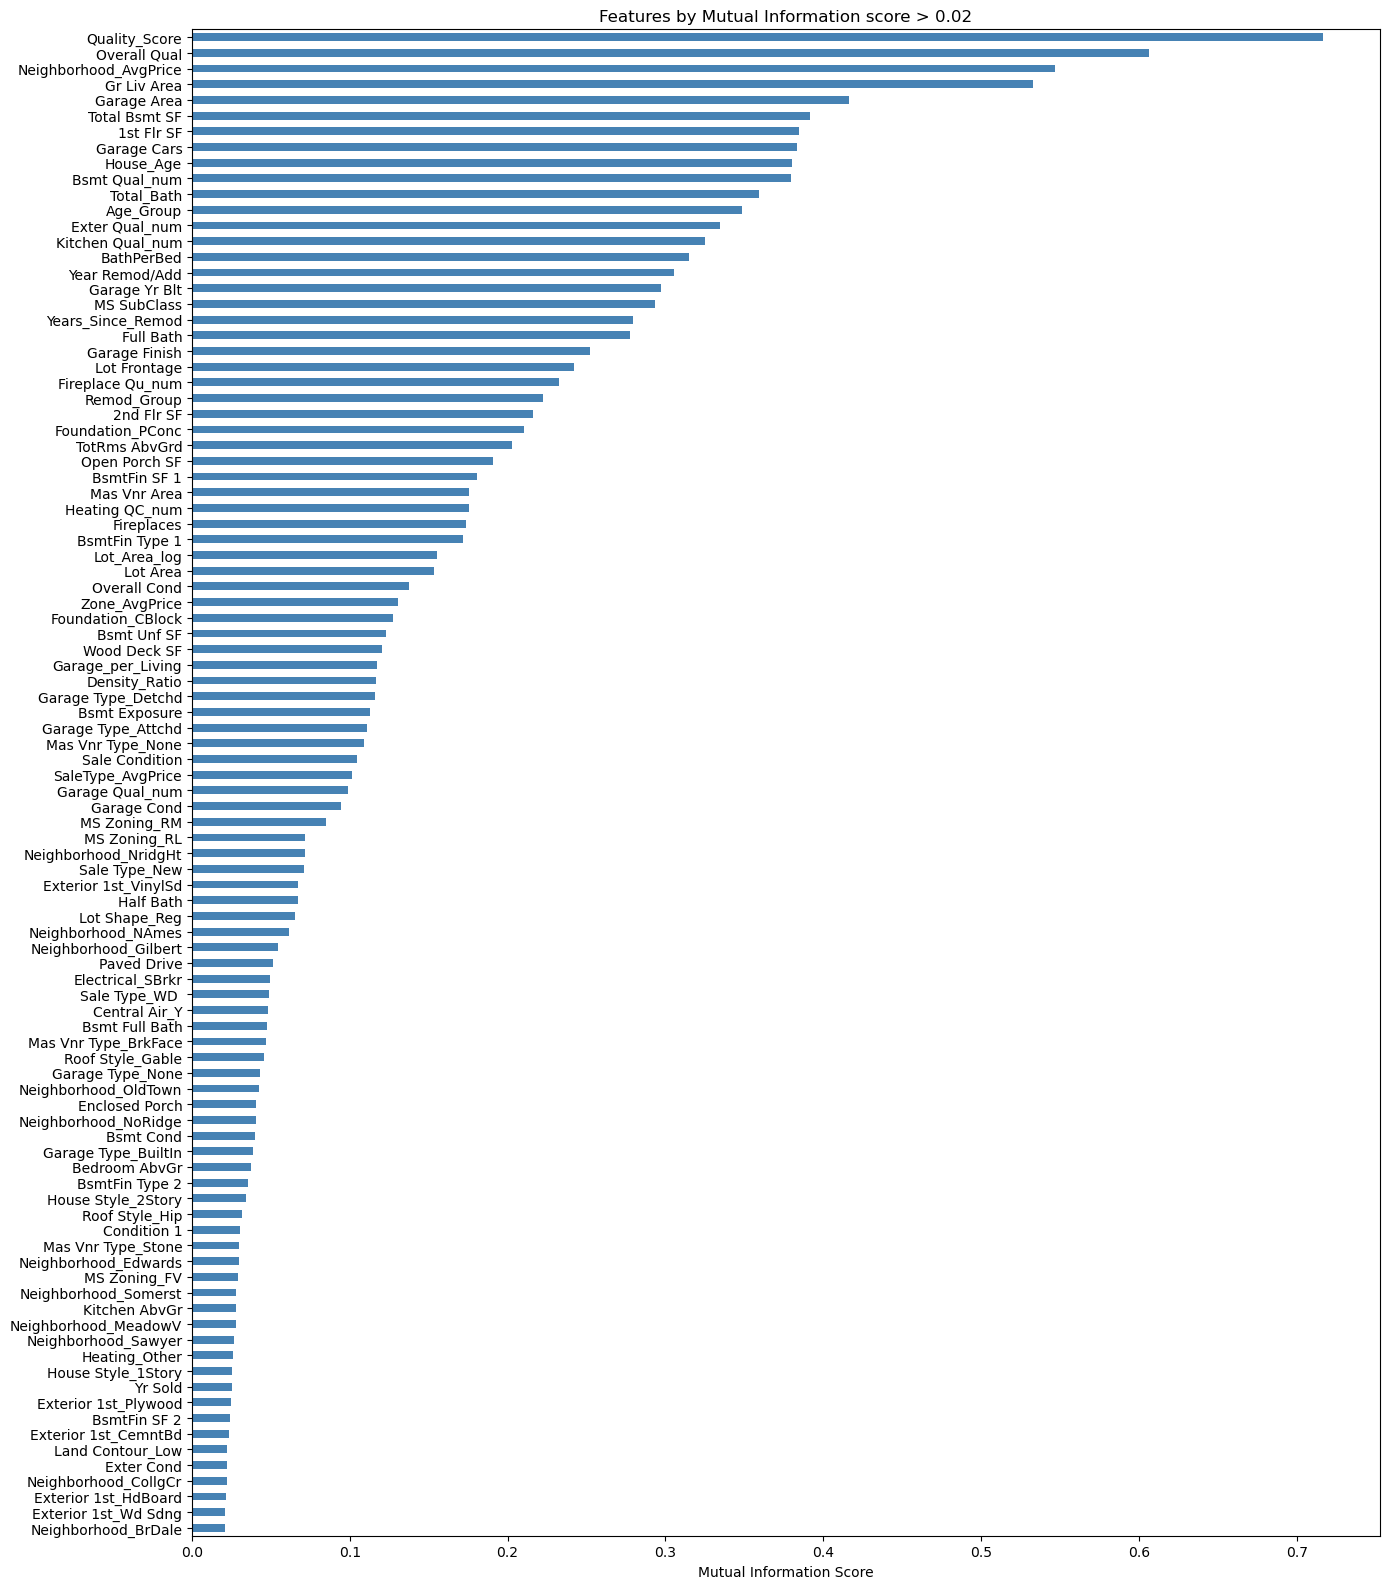

In [392]:
top_mi = mi_series[mi_series > 0.02]
plt.figure(figsize=(14,16))
top_mi.plot(kind='barh', color='steelblue')
plt.xlabel("Mutual Information Score")
plt.title("Features by Mutual Information score > 0.02")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [394]:
print(f"Mean MI score: {mi_series.mean():.4f}")
print(f"Median MI score: {mi_series.median():.4f}")
print(f"Min MI score among selected: {top_mi.min():.4f}")
print(f"Number of features selected: {len(top_mi)}")

Mean MI score: 0.0858
Median MI score: 0.0252
Min MI score among selected: 0.0207
Number of features selected: 96


**Mutual Information Threshold**
- With a threshold of **MI > 0.02**, **96 features** were selected.
- Features below this score contribute almost no information to SalePrice.
- Low‑MI features (MI < 0.02)  remove to reduce noise and overfitting.

In [395]:
selected_features = top_mi.index.tolist()

X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected = X_test_scaled[selected_features]

print(X_train_scaled_selected.shape)
print(X_test_scaled_selected.shape)

(2283, 96)
(571, 96)


In [396]:
X_train_scaled_selected.head()

,Quality_Score,Overall Qual,Neighborhood_AvgPrice,Gr Liv Area,Garage Area,Total Bsmt SF,1st Flr SF,Garage Cars,House_Age,Bsmt Qual_num,...,Yr Sold,Exterior 1st_Plywood,BsmtFin SF 2,Exterior 1st_CemntBd,Land Contour_Low,Exter Cond,Neighborhood_CollgCr,Exterior 1st_HdBoard,Exterior 1st_Wd Sdng,Neighborhood_BrDale
1411,0.516129,0.444444,201812.568182,-0.646973,0.267475,0.279250,0.327613,0.4,-0.189396,0.8,...,2008,0,-0.296663,0,0,0.75,1,1,0,0
2712,0.483871,0.444444,201812.568182,-1.065587,-0.808021,0.313833,0.248440,0.2,0.046625,0.8,...,2006,0,-0.296663,0,0,0.75,1,1,0,0
841,0.548387,0.444444,201812.568182,-1.286235,-0.628772,0.279250,0.206708,0.2,0.046625,0.6,...,2009,0,-0.296663,0,0,0.75,1,1,0,0
651,0.419355,0.333333,122343.444934,-0.925362,-0.897646,0.130899,0.149376,0.2,2.474273,0.4,...,2009,0,-0.296663,0,0,0.50,0,0,0,0
2216,0.838710,0.777778,246599.541667,0.594433,1.135420,0.559793,0.562402,0.6,-1.167199,1.0,...,2007,0,-0.296663,0,0,0.75,0,0,0,0


In [397]:
# save selected features and dataset

X_train_scaled_selected.to_csv("X_train_scaled_selected.csv", index=False)
X_test_scaled_selected.to_csv("X_test_scaled_selected.csv", index=False)

with open("selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)

## Dimensionality Reduction (using PCA)

In [407]:
from sklearn.decomposition import PCA

pca_selected = PCA(n_components=10, random_state=42)

# Fit on training data
X_train_pca = pca_selected.fit_transform(X_train_scaled_selected)

# Transform test data
X_test_pca = pca_selected.transform(X_test_scaled_selected)

print(f"Original features: {X_test_scaled_selected.shape[1]}")
print(f"PCA components : {X_train_pca.shape[1]}")
print(f"Explained variance: {pca_selected.explained_variance_ratio_.sum():.2%}")

Original features: 96
PCA components : 10
Explained variance: 100.00%


In [408]:
pca_columns = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
df_pca = pd.DataFrame(X_train_pca, columns=pca_columns)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,20341.301504,-2.426548,0.148070,-0.410934,1.176509,-1.015239,1.946848,-0.920965,-1.100195,-0.290727
1,20341.301481,-1.072041,-1.484023,0.384095,-0.628518,-1.899237,-0.540729,-0.043613,0.365602,-1.172194
2,20341.301478,-2.151462,-0.863888,-1.095569,1.718542,-0.312267,-0.559197,-0.211748,-0.012652,-0.585085
3,-59127.821796,0.162374,-1.586004,1.136518,2.128401,-0.113495,1.118153,-1.036520,-1.118125,-0.368210
4,65128.275062,-1.643530,-0.891794,1.124058,-1.428297,0.652394,-0.531272,0.560783,-0.393246,0.453070


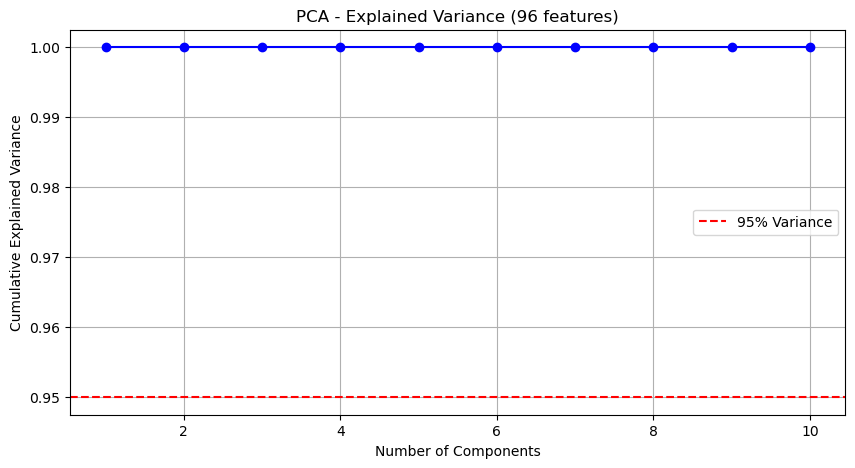

In [409]:
cumsum = np.cumsum(pca_selected.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance (96 features)')
plt.legend()
plt.grid(True)
plt.show()

- *Number of components**: 10 (fixed)
- **Total explained variance**: 100%
- **Original features**: 96


This happens because the original 96 features are **highly linearly correlated**.  
After feature engineering (ratios, interactions, aggregations), most features become linear combinations of a few underlying factors (e.g., house size, quality, location).  


This confirms that the original features lie in a **10‑dimensional linear subspace**.  
The transformed dataset is now ready for modeling.

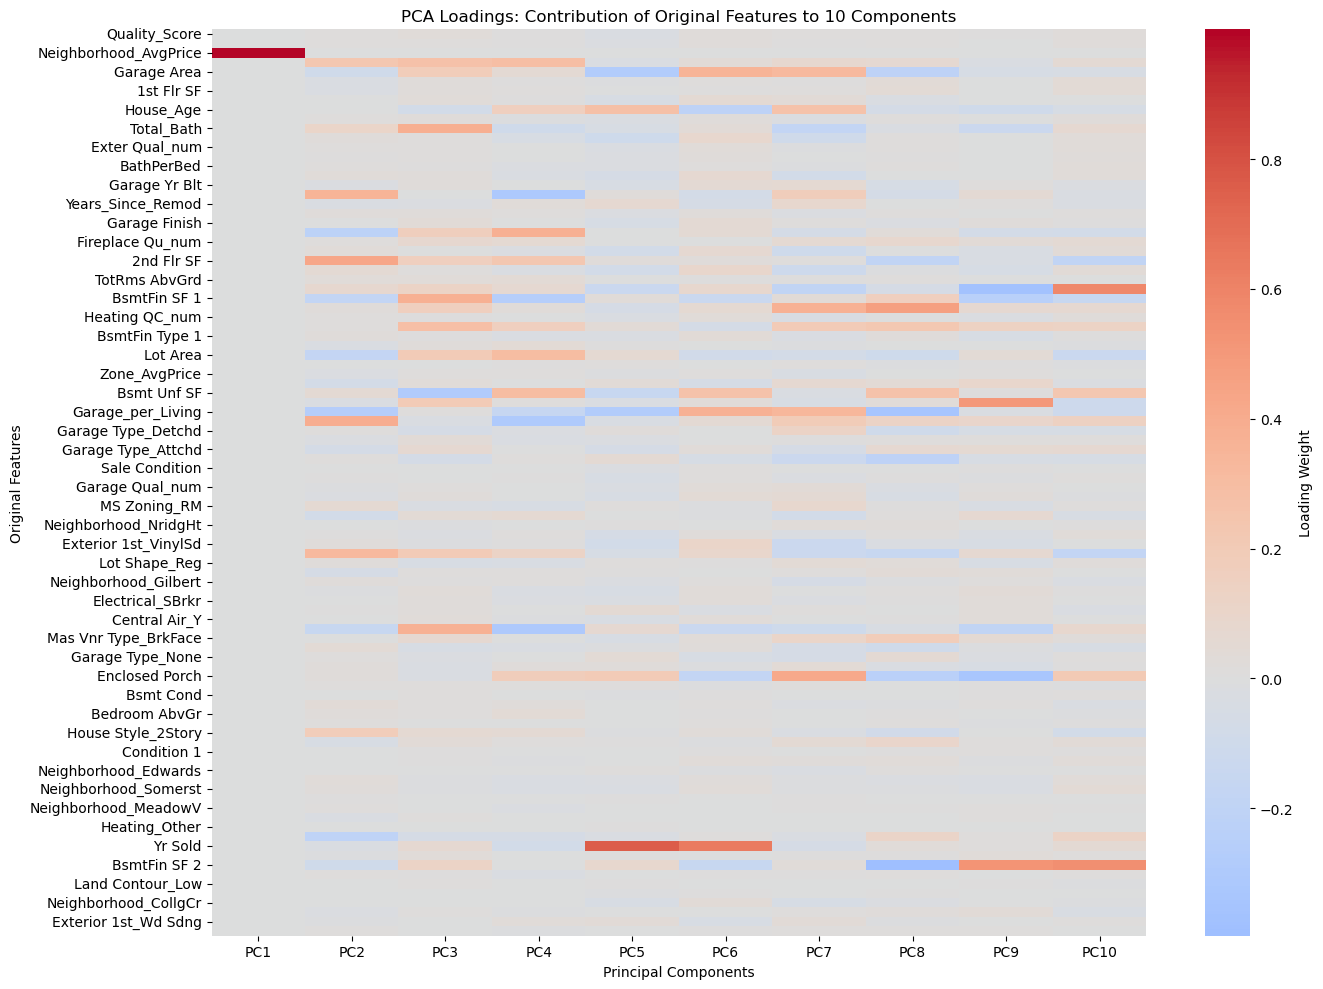

In [411]:

loadings = pca_selected.components_.T 

component_names = [f"PC{i+1}" for i in range(loadings.shape[1])]

feature_names = X_train_scaled_selected.columns

loadings_df = pd.DataFrame(
    loadings,
    index=feature_names,
    columns=component_names
)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings_df.iloc[:, :], 
            cmap='coolwarm', 
            center=0,
            annot=False, 
            fmt='.2f',
            cbar_kws={'label': 'Loading Weight'})
plt.title('PCA Loadings: Contribution of Original Features to 10 Components')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.show()

- The heatmap shows that **all features contribute almost equally to the first few components**.
- This suggests that the original 96 features are **highly correlated** and lie in a low‑dimensional subspace.
- PC1 captures the **overall size & quality** of the house (all area and quality features have similar positive loadings).
- PC2 captures **secondary variations** (possibly location or basement features).
- The uniform loading pattern confirms that **feature engineering generated a dense, correlated feature set**.

In [415]:
# save final datasets
X_train_pca.to_csv("X_train_pca.csv", index=False)
X_test_pca.to_csv("X_test_pca.csv", index=False)

y_train.reset_index(drop=True).to_csv("y_train.csv", index=False, header=["SalePrice"])
y_test.reset_index(drop=True).to_csv("y_test.csv", index=False, header=["SalePrice"])

In [420]:
import plotly.express as px

df_3d = X_train_pca.copy()
df_3d['SalePrice'] = y_train.values

df_3d['Price_Group'] = pd.cut(df_3d['SalePrice'], 
                              bins=[0, 150000, 250000, 800000], 
                              labels=['Low', 'Medium', 'High'])

fig = px.scatter_3d(
    df_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3', 
    color='Price_Group',
    title='PCA 3D - Colored by Price Group',
    color_discrete_map={'Low': 'blue', 'Medium': 'green', 'High': 'red'}
)

fig.show()

This 3D visualization confirms that PCA preserves meaningful price patterns. The clear separation between low and high price houses suggests that the first three components capture the most important price‑related variations.



## Reflective Question

### **When is feature engineering a nice-to-have option, and when is it a must-have?**

- Feature Engineering is **nice‑to‑have** when you have large data and non‑linear models (Deep Learning, XGBoost).
- It is a **must‑have** when data is small, you use linear models, or interpretability is critical (medicine, finance).

- For example in this priject :

**Nice‑to‑Have**: Total Bath (Full Bath + 0.5*Half Bath + Bsmt Full Bath) – A tree model could eventually learn that full baths are more important than half baths, but manually creating this feature makes the learning easier and faster.

 **Nice‑to‑Have**: House Age (Yr Sold - Year Built) – A gradient boosting model might discover age trends, but explicitly providing age avoids capturing random yearly fluctuations.

 **Must‑Have**: Quality_Score (average of multiple quality ratings) – Linear models cannot automatically combine ordinal categories (Ex, Gd, TA, Fa, Po) into a single meaningful score without manual feature engineering.